# Vision-Language Prompt Learning 
**Zero-shot CLIP vs CoCoOp**

Datasets: Oxford Pets · EuroSAT · DTD

In [ ]:
import os, sys
from pathlib import Path


PROJECT = Path(r'C:\Users\Amol\OneDrive\Desktop\Promt\new5')

os.chdir(PROJECT)
sys.path.insert(0, str(PROJECT))


(PROJECT / 'data').mkdir(exist_ok=True)
(PROJECT / 'results').mkdir(exist_ok=True)

print('Working dir:', os.getcwd())
print('Files found:', os.listdir('.'))

Working dir: C:\Users\Amol\OneDrive\Desktop\Promt\new5
Files found: ['.git', 'config.py', 'data', 'datasets.py', 'engine.py', 'main.py', 'models.py', 'requirements.txt', 'results', 'sample.jpg', 'sample1.jpg', 'sample2.jpg', 'utils.py', 'vision-language-prompt-learning.ipynb', 'visualize.py', '__pycache__']


In [ ]:
import subprocess, torch

print('CUDA available:', torch.cuda.is_available())
print('CUDA devices  :', torch.cuda.device_count())
if torch.cuda.is_available():
    torch.cuda.set_device(0)
    print('PyTorch device:', f'cuda:{torch.cuda.current_device()}')
    print('NVIDIA GPU    :', torch.cuda.get_device_name(0))
    vram = torch.cuda.get_device_properties(0).total_memory / 1e9
    print(f'VRAM          : {vram:.1f} GB')

    subprocess.run(['nvidia-smi'], check=False)

CUDA available: True
CUDA devices  : 1
PyTorch device: cuda:0
NVIDIA GPU    : NVIDIA GeForce RTX 3050 Laptop GPU
VRAM          : 4.3 GB


--- 
## Step 1: Cache Zero-Shot Baselines
Run this first to cache the image features and log the baselines.

In [ ]:
DATASET = 'dtd'

%run main.py \
    --data_root ./data \
    --dataset {DATASET} \
    --backbone ViT-B/16 \
    --batch_size 32 \
    --cuda_device 0 \
    --skip_cocoop

Device : cuda:0  |  NVIDIA GeForce RTX 3050 Laptop GPU  (4.3 GB)
Dataset : dtd  |  Backbone : ViT-B/16

Classes : 47  |  test batches : 59

[Zero-shot] caching image features …


  caching images: 100%|██████████| 59/59 [00:20<00:00,  2.82it/s]


[Zero-shot] evaluating 80 templates …


  templates: 100%|██████████| 80/80 [00:44<00:00,  1.79it/s]


  ensemble  top1=44.20%  top5=74.63%
  LLM       top1=45.69%  top5=76.28%
  saved → results\zeroshot_dtd.png
  saved → results\comparison_dtd.png
  saved → results\results_dtd.json  |  results\results_dtd.csv

Method                  Top-1    Top-5
────────────────────────────────────────
ZS-handcrafted         44.20%   74.63%
ZS-LLM                 45.69%   76.28%


In [ ]:
DATASET = 'eurosat'

%run main.py \
    --data_root ./data \
    --dataset {DATASET} \
    --backbone ViT-B/16 \
    --batch_size 32 \
    --cuda_device 0 \
    --skip_cocoop

Device : cuda:0  |  NVIDIA GeForce RTX 3050 Laptop GPU  (4.3 GB)
Dataset : eurosat  |  Backbone : ViT-B/16

Classes : 10  |  test batches : 844

[Zero-shot] caching image features …


  caching images: 100%|██████████| 844/844 [03:06<00:00,  4.53it/s]


[Zero-shot] evaluating 80 templates …


  templates: 100%|██████████| 80/80 [00:10<00:00,  7.43it/s]


  ensemble  top1=54.30%  top5=91.03%
  LLM       top1=52.76%  top5=94.71%
  saved → results\zeroshot_eurosat.png
  saved → results\comparison_eurosat.png
  saved → results\results_eurosat.json  |  results\results_eurosat.csv

Method                  Top-1    Top-5
────────────────────────────────────────
ZS-handcrafted         54.30%   91.03%
ZS-LLM                 52.76%   94.71%


In [4]:
DATASET = 'oxford_pets'

%run main.py \
    --data_root ./data \
    --dataset {DATASET} \
    --backbone ViT-B/16 \
    --batch_size 32 \
    --cuda_device 0 \
    --skip_cocoop

Device : cuda:0  |  NVIDIA GeForce RTX 3050 Laptop GPU  (4.3 GB)
Dataset : oxford_pets  |  Backbone : ViT-B/16

Classes : 37  |  test batches : 115

[Zero-shot] caching image features …


  caching images: 100%|██████████| 115/115 [00:37<00:00,  3.07it/s]


[Zero-shot] evaluating 80 templates …


  templates: 100%|██████████| 80/80 [00:36<00:00,  2.18it/s]


  ensemble  top1=88.06%  top5=97.49%
  LLM       top1=90.19%  top5=99.32%
  saved → results\zeroshot_oxford_pets.png
  saved → results\comparison_oxford_pets.png
  saved → results\results_oxford_pets.json  |  results\results_oxford_pets.csv

Method                  Top-1    Top-5
────────────────────────────────────────
ZS-handcrafted         88.06%   97.49%
ZS-LLM                 90.19%   99.32%


--- 
## Step 2: Train CoCoOp
Trains CoCoOp on few-shot data and generates the comparison chart.

In [ ]:

DATASET = 'dtd'

%run main.py \
    --data_root ./data \
    --dataset {DATASET} \
    --backbone ViT-B/16 \
    --shots 16 \
    --epochs 10 \
    --n_ctx 16 \
    --lr 2e-3 \
    --batch_size 2 \
    --cuda_device 0 \
    --eval_freq 5 \
    --skip_zeroshot

Device : cuda:0  |  NVIDIA GeForce RTX 3050 Laptop GPU  (4.3 GB)
Dataset : dtd  |  Backbone : ViT-B/16

Classes : 47  |  test batches : 940

[Zero-shot] skipped — using cached baselines.

[CoCoOp] image-conditioned dynamic prompts …
  [CoCoOp] caching test features …


  [CoCoOp] caching train features …


  train=752  test=1880


  [CoCoOp] epoch   5  loss=1.4542  top1=55.69%


  [CoCoOp] epoch  10  loss=1.2126  top1=57.39%
  saved → results\cocoop_curves_dtd.png
  weights saved → results/cocoop_weights_dtd.pth
  saved → results\comparison_dtd.png
  saved → results\results_dtd.json  |  results\results_dtd.csv

Method                  Top-1    Top-5
────────────────────────────────────────
ZS-handcrafted         44.20%   74.63%
ZS-LLM                 45.69%   76.28%
CoCoOp                 57.39%   86.81%


In [6]:

DATASET = 'eurosat'

%run main.py \
    --data_root ./data \
    --dataset {DATASET} \
    --backbone ViT-B/16 \
    --shots 16 \
    --epochs 10 \
    --n_ctx 16 \
    --lr 2e-3 \
    --batch_size 2 \
    --cuda_device 0 \
    --eval_freq 5 \
    --skip_zeroshot

Device : cuda:0  |  NVIDIA GeForce RTX 3050 Laptop GPU  (4.3 GB)
Dataset : eurosat  |  Backbone : ViT-B/16

Classes : 10  |  test batches : 13500

[Zero-shot] skipped — using cached baselines.

[CoCoOp] image-conditioned dynamic prompts …
  [CoCoOp] caching test features …


  [CoCoOp] caching train features …


  train=160  test=27000


  [CoCoOp] epoch   5  loss=1.1680  top1=71.01%


  [CoCoOp] epoch  10  loss=0.9758  top1=74.19%
  saved → results\cocoop_curves_eurosat.png
  weights saved → results/cocoop_weights_eurosat.pth
  saved → results\comparison_eurosat.png
  saved → results\results_eurosat.json  |  results\results_eurosat.csv

Method                  Top-1    Top-5
────────────────────────────────────────
ZS-handcrafted         54.30%   91.03%
ZS-LLM                 52.76%   94.71%
CoCoOp                 74.19%   97.96%


In [1]:
DATASET = 'oxford_pets'

%run main.py \
    --data_root ./data \
    --dataset {DATASET} \
    --backbone ViT-B/16 \
    --shots 16 \
    --epochs 10 \
    --n_ctx 16 \
    --lr 2e-3 \
    --batch_size 2 \
    --cuda_device 0 \
    --eval_freq 5 \
    --skip_zeroshot

Device : cuda:0  |  NVIDIA GeForce RTX 3050 Laptop GPU  (4.3 GB)
Dataset : oxford_pets  |  Backbone : ViT-B/16

Classes : 37  |  test batches : 1835

[Zero-shot] skipped — using cached baselines.

[CoCoOp] image-conditioned dynamic prompts …
  [CoCoOp] caching test features …


  [CoCoOp] caching train features …


  train=592  test=3669


  [CoCoOp] epoch   5  loss=0.3108  top1=92.97%


  [CoCoOp] epoch  10  loss=0.2531  top1=93.54%
  saved → results\cocoop_curves_oxford_pets.png
  weights saved → results/cocoop_weights_oxford_pets.pth
  saved → results\comparison_oxford_pets.png
  saved → results\results_oxford_pets.json  |  results\results_oxford_pets.csv

Method                  Top-1    Top-5
────────────────────────────────────────
ZS-handcrafted         88.06%   97.49%
ZS-LLM                 90.19%   99.32%
CoCoOp                 93.54%   99.86%


--- 
## Step 3: Hyperparameter Sweep
Runs 18 CoCoOp configurations to generate Sensitivity Analysis charts.

In [ ]:
DATASET = 'dtd'

%run main.py \
    --data_root ./data \
    --dataset {DATASET} \
    --backbone ViT-B/16 \
    --shots 16 \
    --epochs 5 \
    --batch_size 2 \
    --cuda_device 0 \
    --skip_zeroshot \
    --skip_cocoop \
    --hp_sweep

--- 
## Step 4: Attention Map Visualization

Loading ViT-B/16 and eurosat architecture...
Processing image for class: 'highway or road'

Saved! Open results/heatmap_eurosat.png to see the results.


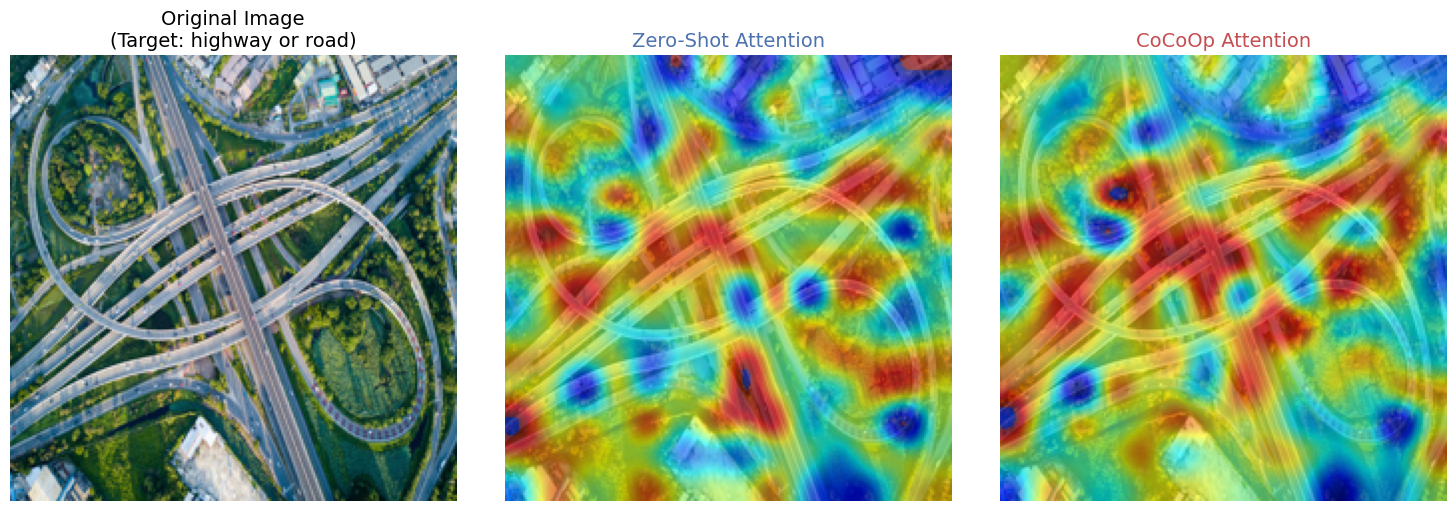

In [1]:
%run visualize.py